# Homework 3: Exploratory Data Analysis of Olympics Reddit Data
Time Tracker:



In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Базові налаштування для графіків
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Завантаження даних
df_posts = pd.read_csv('data/final_submissions.csv', low_memory=False)
df_comments = pd.read_csv('data/final_comments.csv', low_memory=False)

print("Бібліотеки підключено, дані успішно завантажено!")

Бібліотеки підключено, дані успішно завантажено!


## 1. Overview

In [18]:
# Виведення розміру датасетів
print(f"Кількість постів: {df_posts.shape[0]}, стовпців: {df_posts.shape[1]}")
print(f"Кількість коментарів: {df_comments.shape[0]}, стовпців: {df_comments.shape[1]}")

Кількість постів: 77399, стовпців: 118
Кількість коментарів: 2700676, стовпців: 73


In [19]:
df_posts.info()

<class 'pandas.DataFrame'>
RangeIndex: 77399 entries, 0 to 77398
Columns: 118 entries, _meta to crosspost_parent_list
dtypes: bool(28), float64(19), int64(13), object(4), str(54)
memory usage: 55.2+ MB


Висновок. У нашому розпорядженні є два набори даних: сабміти (77 399 рядків, 118 стовпців) та коментарі (понад 2.7 мільйона рядків, 73 стовпці). Основні стовпці містять інформацію про ідентифікатори, час створення (created_utc), текст, кількість балів (score) та назви сабреддітів. Критичні пропущені значення у базових полях відсутні.

## 2. Exploratory Data Analysis & Visualizations

In [20]:
import pandas as pd
import plotly.express as px

# Перетворюємо дати та створюємо стовпчик місяця
df_posts['date'] = pd.to_datetime(df_posts['created_utc'], unit='s', errors='coerce')
df_posts['month'] = df_posts['date'].dt.to_period('M').astype(str)

# Групуємо дані
df_grouped = (
    df_posts.groupby(['month', 'subreddit'])
    .size()
    .unstack(fill_value=0)
    .stack()
    .reset_index(name='post_count')
)

# Сортуємо за місяцем
df_grouped = df_grouped.sort_values('month')

# Будуємо графік
fig = px.area(
    df_grouped, 
    x='month', 
    y='post_count', 
    color='subreddit',
    title='Activity dynamics of submissions over time',
    labels={
        'month': 'Month', 
        'post_count': 'Post count', 
        'subreddit': 'Subreddit'
    }
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Post count",
    hovermode="x unified"
)

fig.show()

In [21]:
import pandas as pd
import plotly.express as px

# Перетворюємо дати та створюємо стовпчик місяця
df_comments['date'] = pd.to_datetime(df_comments['created_utc'], unit='s', errors='coerce')
df_comments['month'] = df_comments['date'].dt.to_period('M').astype(str)

# Групуємо дані 
df_comments_grouped = (
    df_comments.groupby(['month', 'subreddit'])
    .size()
    .unstack(fill_value=0)
    .stack()
    .reset_index(name='comment_count')
)

# Сортуємо за місяцем
df_comments_grouped = df_comments_grouped.sort_values('month')

# Будуємо інтерактивний графік 
fig_comments = px.area(
    df_comments_grouped, 
    x='month', 
    y='comment_count', 
    color='subreddit',
    title='Activity dynamics of comments over time',
    labels={
        'month': 'Month', 
        'comment_count': 'Comment count', 
        'subreddit': 'Subreddit'
    }
)

fig_comments.update_layout(
    xaxis_title="Month",
    yaxis_title="Comment count",
    hovermode="x unified"
)

fig_comments.show()

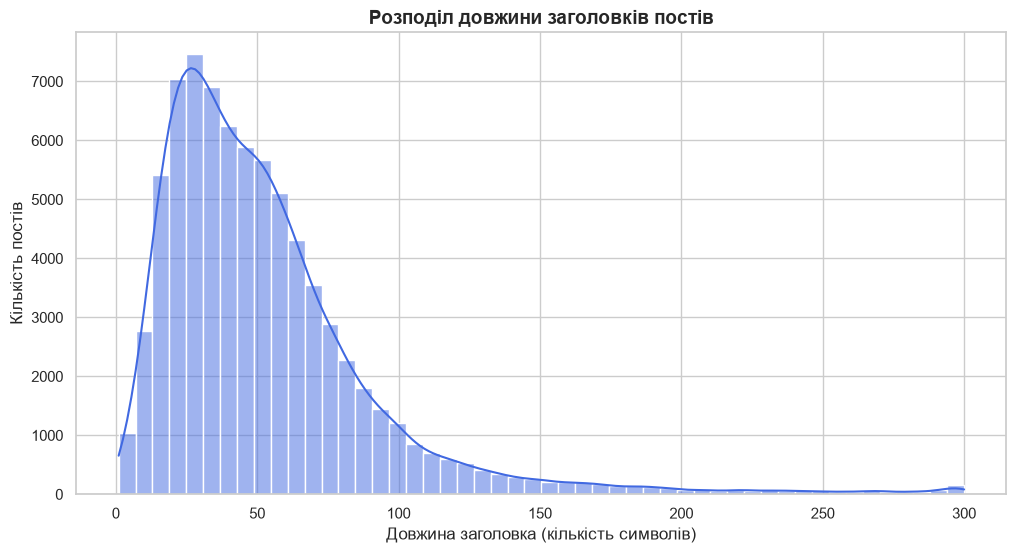

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Створюємо новий стовпчик із довжиною кожного заголовка 
df_posts['title_length'] = df_posts['title'].fillna('').astype(str).str.len()

plt.figure(figsize=(12, 6))

# Будуємо гістограму розподілу 
sns.histplot(
    data=df_posts, 
    x='title_length', 
    bins=50, 
    color='royalblue', 
    kde=True
)


plt.title('Розподіл довжини заголовків постів', fontsize=14, fontweight='bold')
plt.xlabel('Довжина заголовка (кількість символів)', fontsize=12)
plt.ylabel('Кількість постів', fontsize=12)

plt.show()

In [ ]:
import pandas as pd
import plotly.express as px

# Рахуємо довжину заголовка для кожного поста
df_posts['title_length'] = df_posts['title'].fillna('').astype(str).str.len()

# Групуємо по місяцях і знаходимо середню довжину заголовка
df_line = df_posts.groupby('month')['title_length'].mean().reset_index()
df_line = df_line.sort_values('month')

# Будуємо лінійний графік 
fig = px.line(
    df_line, 
    x='month', 
    y='title_length', 
    markers=True,
    title='Динаміка середньої довжини заголовків у часі',
    labels={
        'month': 'Місяць', 
        'title_length': 'Середня довжина заголовка (символів)'
    }
)

fig.update_layout(
    xaxis_title="Місяць",
    yaxis_title="Середня довжина (символів)",
    hovermode="x unified"
)

fig.update_yaxes(rangemode="tozero")

fig.show()

In [15]:
deleted_count = df_comments['body'].isin(['[deleted]', '[removed]']).sum()
print(f"Кількість видалених коментарів: {deleted_count}")

Кількість видалених коментарів: 73223


Перевірка показала наявність великої кількості видалених коментарів. Оскільки слова [deleted] та [removed] мають малу довжину, вони суттєво занижують реальну середню довжину тексту. Відфільтруємо їх перед побудовою графіка.

In [ ]:
import pandas as pd
import plotly.express as px

df_clean_comments = df_comments[~df_comments['body'].isin(['[deleted]', '[removed]'])].copy()

df_clean_comments['comment_length'] = df_clean_comments['body'].fillna('').astype(str).str.len()

# Групуємо по місяцях і знаходимо середню довжину коментаря
df_comments_line = df_clean_comments.groupby('month')['comment_length'].mean().reset_index()
df_comments_line = df_comments_line.sort_values('month')

# Будуємо лінійний графік 
fig_comments_line = px.line(
    df_comments_line, 
    x='month', 
    y='comment_length', 
    markers=True,
    title='Динаміка середньої довжини коментарів у часі',
    labels={
        'month': 'Місяць', 
        'comment_length': 'Середня довжина коментаря (символів)'
    }
)

fig_comments_line.update_layout(
    xaxis_title="Місяць",
    yaxis_title="Середня довжина (символів)",
    hovermode="x unified"
)

fig_comments_line.update_yaxes(rangemode="tozero")

fig_comments_line.show()

In [ ]:
import pandas as pd
import plotly.express as px
import re
from collections import Counter

all_titles = ' '.join(df_posts['title'].dropna().astype(str)).lower()

words = re.findall(r'\b[a-z]+\b', all_titles)

# Список стоп-слів 
stop_words = {
    'the', 'to', 'and', 'in', 'of', 'for', 'a', 'on', 'is', 'at', 'i', 'with', 
    'it', 'this', 'that', 'olympics', 'olympic', 'my', 'how', 'are', 'you', 'was', 'what', 
    'do', 'from', 'as', 'be', 'have', 'or', 'by', 'but', 'not', 'can', 'about',
    'after', 'who', 'why', 'will', 'his', 'he', 'she', 'they', 'we', 'just', 'all', 'out', 'has', 'up', 'if', 'out', 'so'
}

filtered_words = [word for word in words if word not in stop_words and len(word) > 2]

# Рахуємо частоту слів 
word_counts = Counter(filtered_words)
df_top_words = pd.DataFrame(word_counts.most_common(15), columns=['word', 'count'])

df_top_words = df_top_words.sort_values(by='count', ascending=True)

# Будуємо горизонтальний Bar Chart
fig_words = px.bar(
    df_top_words,
    x='count',
    y='word',
    orientation='h',
    title='Топ-15 найпопулярніших слів у заголовках постів',
    labels={'count': 'Кількість згадок', 'word': 'Слово'},
    text_auto=True,
    color='count',
    color_continuous_scale='Teal' 
)

fig_words.update_layout(
    xaxis_title="Кількість згадок",
    yaxis_title="Слово"
)

fig_words.show()

In [31]:
import pandas as pd
import plotly.express as px
import re
from collections import Counter

# Список стоп-слів 
stop_words = {
    'the', 'to', 'and', 'in', 'of', 'for', 'a', 'on', 'is', 'at', 'i', 'with', 
    'it', 'this', 'that', 'olympics', 'olympic', 'my', 'how', 'are', 'you', 'was', 'what', 
    'do', 'from', 'as', 'be', 'have', 'or', 'by', 'but', 'not', 'can', 'about',
    'after', 'who', 'why', 'will', 'his', 'he', 'she', 'they', 'we', 'just', 'all', 
    'out', 'has', 'up', 'if', 'so', 'like', 'there', 'would', 'people', 'one', 'more',
    'an', 'their', 'when', 'some', 'get', 'think', 'good', 'even', 'time', 'which', 'me',
    'your', 'her', 'don', 'because', 'him', 'than', 'really', 'had', 'been', 'also', 
    'see', 'only', 'them', 'now', 'much', 'know', 'can', 'did', 'very', 'were', 'then',
    'into', 'could', 'other', 'well', 'going', 'way', 'got', 'make', 'game', 'play'
}

# Оптимізований підрахунок слів
word_counts_comments = Counter()

for text in df_clean_comments['body'].dropna():
    words = re.findall(r'\b[a-z]+\b', str(text).lower())
    filtered = [w for w in words if w not in stop_words and len(w) > 2]
    word_counts_comments.update(filtered)

df_top_comments_words = pd.DataFrame(word_counts_comments.most_common(15), columns=['word', 'count'])
df_top_comments_words = df_top_comments_words.sort_values(by='count', ascending=True)

# Будуємо горизонтальний Bar Chart
fig_comments_words = px.bar(
    df_top_comments_words,
    x='count',
    y='word',
    orientation='h',
    title='Топ-15 найпопулярніших слів у коментарях',
    labels={'count': 'Кількість згадок', 'word': 'Слово'},
    text_auto=True,
    color='count',
    color_continuous_scale='Purp' 
)

fig_comments_words.update_layout(
    xaxis_title="Кількість згадок",
    yaxis_title="Слово"
)

fig_comments_words.show()